In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
#importando as metricas de avaliacao
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
bc_data = load_breast_cancer()

Y = pd.Series(bc_data.target)
X = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
#verificar se tem dados faltantes
print(X.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [3]:
random_state = 42
#separar os dados em teste e treino, com 20% dos dados para teste
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=random_state)

#verificando os dados e o tamanho deles
print("X treino:\n", X_train.head())
print(X_train.shape)
print("X teste:\n", X_test.head())
print(X_test.shape)
print("Y treino:\n", Y_train.head())
print(Y_train.shape)
print("Y teste:\n", Y_test.head())
print(Y_test.shape)

X treino:
      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
68         9.029         17.33           58.79      250.5          0.10660   
181       21.090         26.57          142.70     1311.0          0.11410   
63         9.173         13.86           59.20      260.9          0.07721   
248       10.650         25.22           68.01      347.0          0.09657   
60        10.170         14.88           64.55      311.9          0.11340   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
68            0.14130         0.31300              0.04375         0.2111   
181           0.28320         0.24870              0.14960         0.2395   
63            0.08751         0.05988              0.02180         0.2341   
248           0.07234         0.02379              0.01615         0.1897   
60            0.08061         0.01084              0.01290         0.2743   

     mean fractal dimension  ...  worst radius  worst tex

In [4]:
#usar Support Vector Classifier de estimador
svc = SVC()

parameters = [{'C': [0.5,0.6,0.7,0.8,0.9], 'kernel': ['linear']},
              {'C': [0.5,0.6,0.7,0.8,0.9], 'kernel': ['poly'], 'degree': [2,3,4]},
              {'C': [0.5,0.6,0.7,0.8,0.9], 'kernel': ['rbf'], 'gamma': [0.7, 0.8, 0.9]}]

grid_search = GridSearchCV(estimator = svc, param_grid = parameters, scoring = 'precision', cv = 3)
grid_search = grid_search.fit(X_train, Y_train)
#imprimir resultados
#print(pd.DataFrame(grid_search.cv_results_))
print("A Melhor pontuacao foi: ", grid_search.best_score_)
print("Estimador escolhido: ", grid_search.best_estimator_)

y_pred = grid_search.predict(X_test)

A Melhor pontuacao foi:  0.9552862811791384
Estimador escolhido:  SVC(C=0.7, kernel='linear')


In [5]:
scores = cross_val_score(grid_search.best_estimator_, X_train, Y_train, cv=3)
print("Pontuacao de cada fold:\n", scores)

Pontuacao de cada fold:
 [0.96052632 0.95394737 0.94039735]


In [6]:
#usar Random Forest de estimator
n_estimators = [10,15,20,40,60]
max_features = ['sqrt', 'log2']
max_depth = [2,4,6,8]

parameters_ranfor = {'n_estimators' : n_estimators,
                     'max_features' : max_features,
                     'max_depth' : max_depth,}

ranfor = RandomForestClassifier(random_state=random_state)

ranfor_grid = GridSearchCV(estimator = ranfor, param_grid = parameters_ranfor, scoring='precision', cv = 3)
ranfor_grid.fit(X_train, Y_train)

print("score do ranfor: ", ranfor_grid.score(X_test, Y_test))
print("A Melhor pontuacao foi: ", ranfor_grid.best_score_)
print("Estimador escolhido: ", ranfor_grid.best_estimator_)

y_pred_ranfor = ranfor_grid.predict(X_test)

score do ranfor:  0.9714285714285714
A Melhor pontuacao foi:  0.9619361165752919
Estimador escolhido:  RandomForestClassifier(max_depth=6, max_features='log2', n_estimators=10,
                       random_state=42)


Feature Importances:
 mean radius                0.093684
mean texture               0.014944
mean perimeter             0.038474
mean area                  0.022783
mean smoothness            0.002868
mean compactness           0.025308
mean concavity             0.009294
mean concave points        0.162593
mean symmetry              0.002217
mean fractal dimension     0.001198
radius error               0.045715
texture error              0.010436
perimeter error            0.003710
area error                 0.041074
smoothness error           0.003757
compactness error          0.003810
concavity error            0.005364
concave points error       0.005423
symmetry error             0.001836
fractal dimension error    0.005010
worst radius               0.085216
worst texture              0.021074
worst perimeter            0.084793
worst area                 0.074389
worst smoothness           0.007562
worst compactness          0.025340
worst concavity            0.029586
worst 

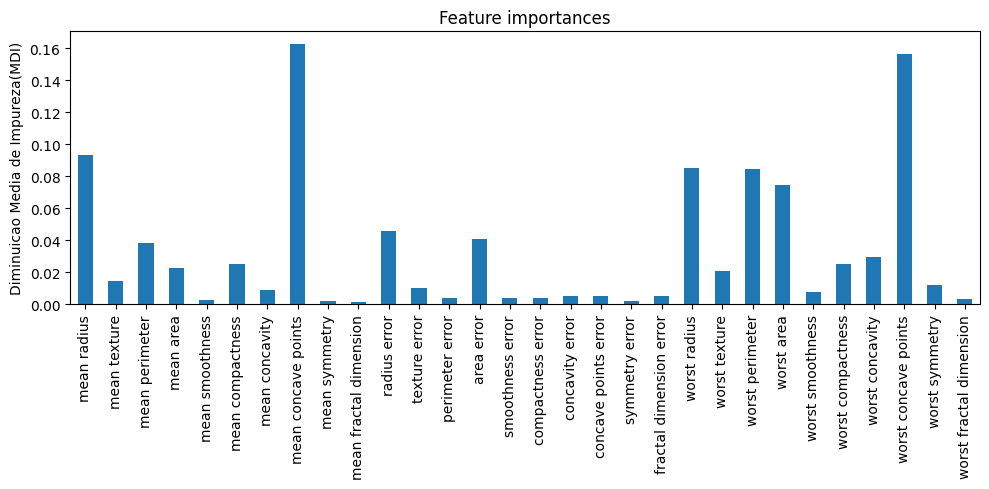

In [7]:
RF2 = RandomForestClassifier(n_estimators=15, min_samples_split=5, random_state=random_state)
RF2.fit(X_train, Y_train)

importances = RF2.feature_importances_
RF2_importances = pd.Series(importances, index=bc_data.feature_names)
print("Feature Importances:\n", RF2_importances)

fig, ax = plt.subplots(figsize=(10, 5))
RF2_importances.plot.bar(ax=ax)
ax.set_title("Feature importances")
ax.set_ylabel("Diminuicao Media de Impureza(MDI)")
fig.tight_layout()

In [8]:
colunas = X.columns[importances < 0.004]
X_train_RF2 = X_train.drop(columns=colunas)
X_test_RF2 = X_test.drop(columns=colunas)
#X_RF2 = X.drop(columns=X.columns[[4,8,9,12,14,15,18,19,24,29]])

RF2.fit(X_train_RF2, Y_train)
y_pred_RF2 = RF2.predict(X_test_RF2)

In [9]:
#fazer matriz de confusao para comparar os valores preditos com valores reais
print("Matriz de confusao do SVC:\n", confusion_matrix(Y_test, y_pred), "\n\n")
print("Matriz de confusao do Random Forest (Grid Search):\n", confusion_matrix(Y_test, y_pred_ranfor), "\n\n")
print("Matriz de confusao do Random Forest:\n", confusion_matrix(Y_test, y_pred_RF2), "\n\n")

Matriz de confusao do SVC:
 [[40  3]
 [ 1 70]] 


Matriz de confusao do Random Forest (Grid Search):
 [[41  2]
 [ 3 68]] 


Matriz de confusao do Random Forest:
 [[40  3]
 [ 2 69]] 




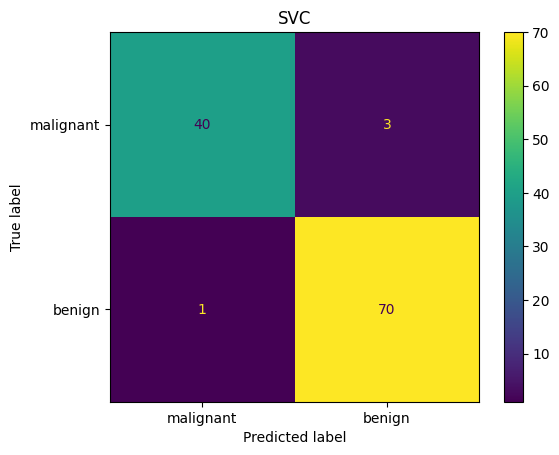

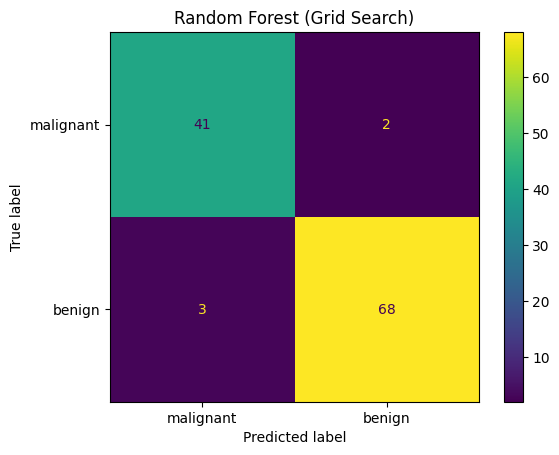

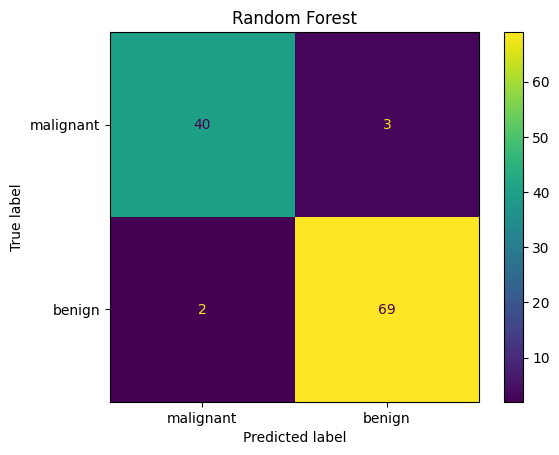

In [10]:
#plotar a matriz de confusao
for modelo, Xt, titulo in [
    (grid_search, X_test, 'SVC'),
    (ranfor_grid, X_test, 'Random Forest (Grid Search)'),
    (RF2, X_test_RF2, 'Random Forest'),
]:
    disp = ConfusionMatrixDisplay.from_estimator(modelo, Xt, Y_test, display_labels=bc_data.target_names)
    disp.ax_.set_title(titulo)

In [11]:
#recall
##calcula a razão tp / (tp + fn), sendo tp true positive e fn false negative. calcula a capacidade do classificador de encontrar todas as amostras positivas.

#precision score
##calcula a precisao fazendo tp / (tp + fp), sendo fp false positive. calcula a capacidade do classificador de nao
#rotular como positiva uma amostra negativa.

#f1 score
##eh a media harmonica da precision e da recall.

print("Classification Report SVC: \n", classification_report(Y_test, y_pred, target_names=bc_data.target_names))
print("\nClassification Report Random Forest (Grid Search): \n", classification_report(Y_test, y_pred_ranfor, target_names=bc_data.target_names))
print("\nClassification Report Random Forest : \n", classification_report(Y_test, y_pred_RF2, target_names=bc_data.target_names))

Classification Report SVC: 
               precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Classification Report Random Forest (Grid Search): 
               precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


Classification Report Random Forest : 
               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   m

In [12]:
print('0: Maligno\n1: Benigno')
print('Valores reais :\n' + str(Y_test.value_counts()))
print('Valores preditos SVC :\n' + str(pd.Series(y_pred).value_counts()))
print('Valores preditos Random Forest (Grid Search) :\n' + str(pd.Series(y_pred_ranfor).value_counts()))
print('Valores preditos Random Forest :\n' + str(pd.Series(y_pred_RF2).value_counts()))

print('Accuracy por feature SVC: %.4f' % (accuracy_score(Y_test, y_pred)/X.shape[1]))
print('\nAccuracy por feature Random Forest (Grid Search): %.4f' % (accuracy_score(Y_test, y_pred_ranfor)/X.shape[1]))
print('\nAccuracy por feature Random Forest : %.4f' % (accuracy_score(Y_test, y_pred_RF2)/X_train_RF2.shape[1]))

0: Maligno
1: Benigno
Valores reais :
1    71
0    43
Name: count, dtype: int64
Valores preditos SVC :
1    73
0    41
Name: count, dtype: int64
Valores preditos Random Forest (Grid Search) :
1    70
0    44
Name: count, dtype: int64
Valores preditos Random Forest :
1    72
0    42
Name: count, dtype: int64
Accuracy por feature SVC: 0.0322

Accuracy por feature Random Forest (Grid Search): 0.0319

Accuracy por feature Random Forest : 0.0435


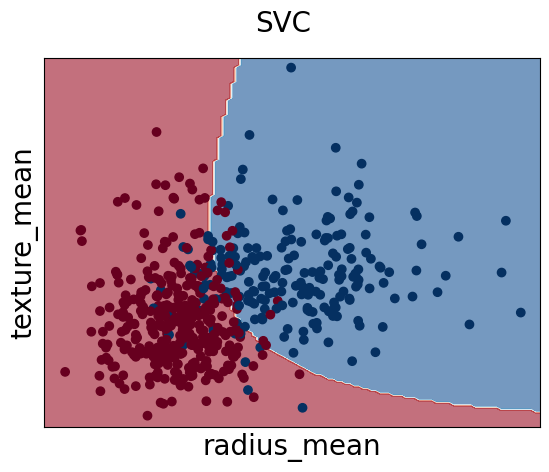

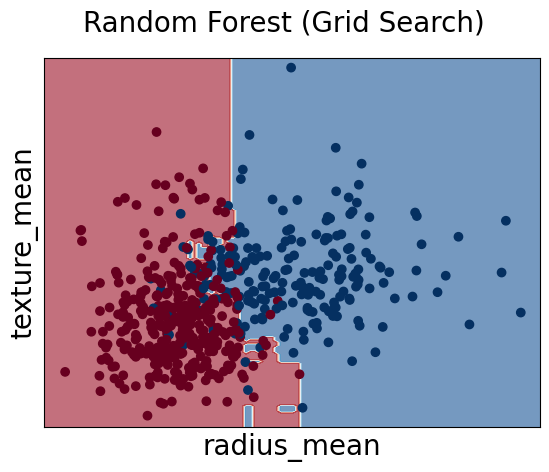

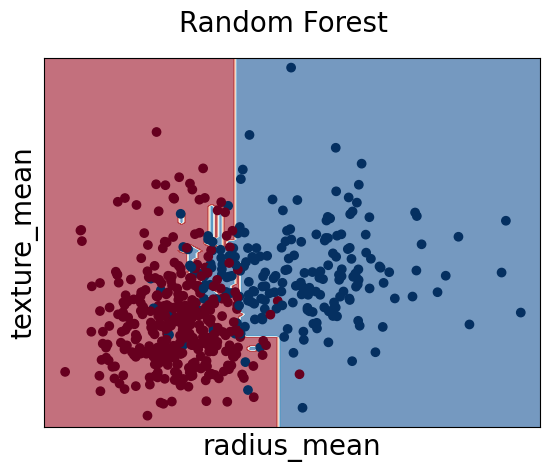

In [13]:
X_cols = X.iloc[:, :2].to_numpy()
X0, X1 = X_cols[:, 0], X_cols[:, 1]
h = 0.2
xx, yy = np.meshgrid(np.arange(X0.min() - 1, X0.max() + 1, h),
                     np.arange(X1.min() - 1, X1.max() + 1, h))

def plota_fronteira(modelo, titulo):
    modelo = clone(modelo).fit(X_cols, Y)
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, cmap='RdBu_r', alpha=0.6)
    plt.scatter(X0, X1, c=Y, cmap='RdBu_r')
    plt.xlabel('radius_mean', size=20)
    plt.ylabel('texture_mean', size=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.suptitle(titulo, size=20)

plota_fronteira(grid_search, 'SVC')
plota_fronteira(ranfor_grid, 'Random Forest (Grid Search)')
plota_fronteira(RF2, 'Random Forest')

plt.show()